In [2]:
import matplotlib.pyplot as plt
from osgeo import gdal
import numpy as np
import warnings
import ternary
import pandas as pd
import geopandas as gpd
import seaborn as sns
import pymannkendall as mk
import matplotlib.ticker as mticker
import ternary
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import matplotlib.ticker as ticker
import cmaps
import cartopy.feature as cf
import cartopy.io.shapereader as shpreader
from scipy.ndimage import zoom
from scipy.signal import savgol_filter
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
warnings.filterwarnings('ignore')

## Figure 1

In [3]:
def read_tif(tif_file):
    """
    Parameters:
    ------------------------------
      - tif_file: the full path of the GeoTIFF data (e.g., "/data/imagery.tif").
      - im_data: (rows, cols, bands)
    """
    dataset = gdal.Open(tif_file)
    cols = dataset.RasterXSize
    rows = dataset.RasterYSize
    im_proj = (dataset.GetProjection())
    im_Geotrans = (dataset.GetGeoTransform())
    im_data = dataset.ReadAsArray(0, 0, cols, rows)
    if im_data.ndim == 3:
        im_data = np.moveaxis(dataset.ReadAsArray(0, 0, cols, rows), 0, -1)

    dataset = None
    im_data = im_data.astype(np.float32)
    im_data[im_data == 0] = np.nan
    return im_data, im_Geotrans, im_proj, rows, cols

In [84]:
"""
Step 1: Reproject the GeoTiff from MODIS Sinusoidal to Antarctic Polar Stereographic (EPSG:3031).
"""

data_path = "/Users/jifujiang/Desktop/Antarctic_greenning_mapping/1_data/"

input_tif = f"{data_path}Years_of_Greenness_appeared_from_2002_to_2023.tif"
output_tif = f"{data_path}Years_of_Greenness_appeared_from_2002_to_2023_EPSG3031.tif"
gdal.Warp(output_tif, input_tif, dstSRS="EPSG:3031", resampleAlg=gdal.GRA_NearestNeighbour)

<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x7fb01007ecf0> >

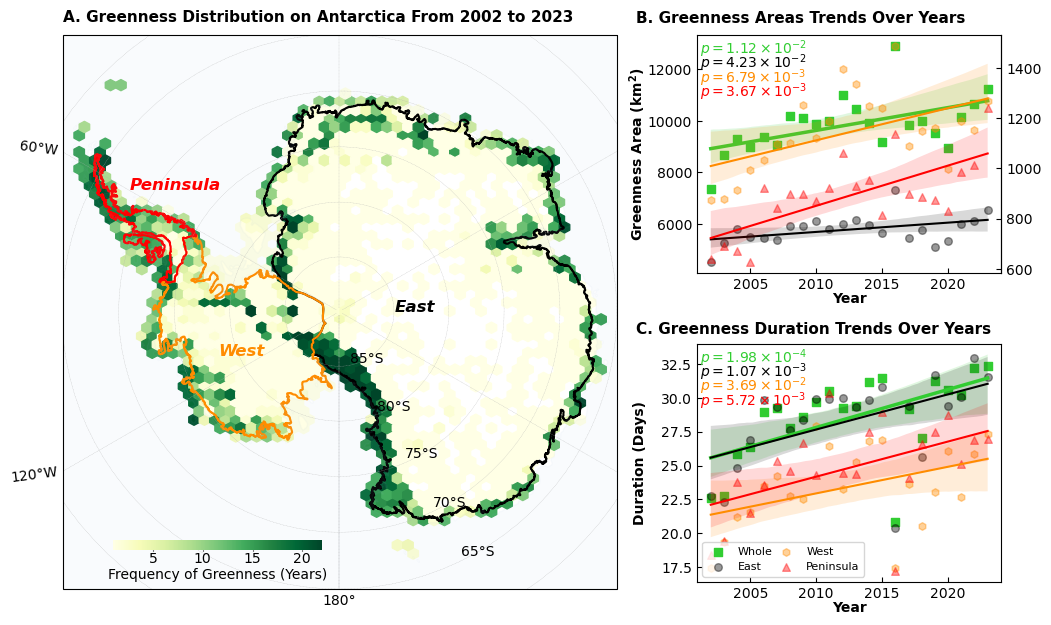

In [8]:
data_path = "/Users/jifujiang/Desktop/Antarctic_greenning_mapping/1_data/"
file_name = f"{data_path}Years_of_Greenness_appeared_from_2002_to_2023_EPSG3031.tif"
shp = gpd.read_file(f"{data_path}shapefile/shapefile_for_regions/regions.shp")
east = shp[shp["Regions"] == "East"]
west = shp[shp["Regions"] == "West"]
pen = shp[shp["Regions"] == "Peninsula"]


df1 = pd.read_csv(f"{data_path}Area.csv")
df2 = pd.read_csv(f"{data_path}Duration.csv")
df3 = pd.read_csv(f"{data_path}Area_by_region.csv")
df4 = pd.read_csv(f"{data_path}Duration_by_region.csv")


im_data, im_Geotrans, im_proj,_,_ = read_tif(file_name)
mask = ~np.isnan(im_data)

height, width = im_data.shape

# Generate grid of coordinates (Antarctic Polar Stereographic)
x_coords = np.arange(0, width) * im_Geotrans[1] + im_Geotrans[0]
y_coords = np.arange(0, height) * im_Geotrans[5] + im_Geotrans[3]

xx, yy = np.meshgrid(x_coords, y_coords)
x_valid, y_valid, data_valid = xx[mask].flatten(), yy[mask].flatten(), im_data[mask].flatten()

#*************************************************************************#
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': ccrs.SouthPolarStereo()}, dpi = 100)

ax.set_extent([-180, 180, -90, -65], crs=ccrs.PlateCarree())
ax.add_feature(cf.OCEAN,alpha=0.05,zorder = 2)
gl = ax.gridlines(draw_labels=True, dms=True, linestyle='--',linewidth=0.2)
gl.top_labels = False
gl.right_labels = False

hb = ax.hexbin(x_valid, y_valid, C=data_valid, gridsize=50,
               transform=ccrs.SouthPolarStereo(), cmap='YlGn', reduce_C_function=np.nanmax)

cb = plt.colorbar(hb, ax=ax, orientation='horizontal', shrink=0.3, pad=0.05, ticks=np.arange(0,21,5), anchor = (0.25,1.9))
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=10,pad = 0.1,length=1)
cb.set_label('Frequency of Greenness (Years)',fontsize = 10,labelpad=2)

east.plot(ax = ax,transform=ccrs.SouthPolarStereo(),color = 'none',edgecolor="k",lw = 1.5)
west.plot(ax = ax,transform=ccrs.SouthPolarStereo(),color = 'none',edgecolor="darkorange",lw = 1.5)
pen.plot(ax = ax,transform=ccrs.SouthPolarStereo(),color = 'none',edgecolor="r",lw = 1.5)

ax.text(0.6,0.5, f'East', transform=ax.transAxes, fontsize = 12,fontweight='bold', fontstyle='italic')
ax.text(0.28,0.42, f'West', transform=ax.transAxes, fontsize = 12,fontweight='bold', fontstyle='italic',color = "darkorange")
ax.text(0.12,0.72, f'Peninsula', transform=ax.transAxes, fontsize = 12,fontweight='bold', fontstyle='italic',color = "red")

#**************************************************#
ax_inset1 = inset_axes(ax, width="55%", height="43%", loc='lower center', bbox_to_anchor=(0.92, 0.557, 1, 1),bbox_transform=ax.transAxes)
ax_inset2 = inset_axes(ax, width="55%", height="43%", loc='lower center', bbox_to_anchor=(0.92, 0, 1, 1),bbox_transform=ax.transAxes)
ax_inset3 = inset_axes(ax, width="55%", height="43%", loc='lower center', bbox_to_anchor=(0.92, 0.557, 1, 1),bbox_transform=ax.transAxes)
ax_inset3.patch.set_alpha(0)
ax_inset3.spines['top'].set_visible(False)
ax_inset3.spines['left'].set_visible(False)
ax_inset3.spines['bottom'].set_visible(False)
ax_inset3.yaxis.set_ticks_position('right')
ax_inset3.xaxis.set_ticks_position('bottom')
ax_inset3.yaxis.set_label_position("right")

#**************************************************#
x, y = df1["Year"], df1["Area(KM2)"]

ax_inset1.scatter(x,y, s=40, marker = "s", color = "limegreen", label = "Whole")
sns.regplot("Year","Area(KM2)", data = df1, ax = ax_inset1,fit_reg=True, ci = 95,scatter=False,line_kws = {'color':'limegreen','lw':2.5})
p = mk.original_test(y).p

p_str = "{:.2e}".format(p)
mantissa, exponent = p_str.split("e")
exponent = int(exponent)
text_str = f"$p = {mantissa}\\times10^{{{exponent}}}$"
ax_inset1.text(0.01,0.92, text_str, transform=ax_inset1.transAxes, fontsize = 10, color = "limegreen")


east_df = df3[df3["Regions"] == "East"]
west_df = df3[df3["Regions"] == "West"]
pen_df = df3[df3["Regions"] == "Peninsula"]

data = [east_df, west_df, pen_df]
labels = ["East", "West", "Peninsula"]
colors = ["k", "darkorange", "r"]
mks = ["o", "h", "^"]
text_loc = [0.06, 0.12, 0.18]


for idx, df in enumerate(data):
    xx, yy = df["year"], df["vegetation_area"]
    p = mk.original_test(yy).p
    p_str = "{:.2e}".format(p)
    mantissa, exponent = p_str.split("e")
    exponent = int(exponent)
    text_str = f"$p = {mantissa}\\times10^{{{exponent}}}$"
    ax_inset1.text(0.01,0.92-text_loc[idx], text_str, transform=ax_inset1.transAxes, fontsize = 10, color = colors[idx])

    if idx == 0:
        ax_inset1.scatter(xx,yy, s=30, marker = mks[idx], color = colors[idx], label = labels[idx], alpha = 0.4)
        sns.regplot("year","vegetation_area", data = df, ax = ax_inset1,fit_reg=True, ci = 95,scatter=False,line_kws = {'color':colors[idx],'lw':1.5})
    else:
        ax_inset3.scatter(xx,yy, s=30, marker = mks[idx], color = colors[idx], label = labels[idx], alpha = 0.4)
        sns.regplot("year","vegetation_area", data = df, ax = ax_inset3,fit_reg=True, ci = 95,scatter=False,line_kws = {'color':colors[idx],'lw':1.5})
        ax_inset3.set_xticklabels([])
        ax_inset3.set_xlabel('')
        ax_inset3.set_ylabel('')
        ax_inset3.tick_params(labelsize=10,direction='in')
        ax_inset3.tick_params(axis='x', which='major', direction='in', length=0)
        

ax_inset1.set_xlabel(f'Year', fontsize=10, labelpad = 0.05, fontweight='bold')
ax_inset1.set_ylabel(r'Greenness Area ($\mathbf{km^2}$)', fontsize=10, labelpad = 0.05,fontweight='bold')
ax_inset1.tick_params(labelsize=10,direction='in')


#**************************************************#
x, y = df2["Year"], df2["Duration(Days)"]
ax_inset2.scatter(x,y, s=40, marker = "s", color = "limegreen", label = "Whole")
sns.regplot("Year","Duration(Days)", data = df2, ax = ax_inset2,fit_reg=True, ci = 95,scatter=False,line_kws = {'color':'limegreen','lw':2.5})

p = mk.original_test(y).p
p_str = "{:.2e}".format(p)
mantissa, exponent = p_str.split("e")
exponent = int(exponent)
text_str = f"$p = {mantissa}\\times10^{{{exponent}}}$"
ax_inset2.text(0.01,0.92, text_str, transform=ax_inset2.transAxes, fontsize = 10, color = "limegreen")


east_df = df4[["year","East"]]
west_df = df4[["year","West"]]
pen_df = df4[["year","Peninsula"]]

data = [east_df, west_df, pen_df]
for idx, df in enumerate(data):
    xx, yy = df["year"], df[labels[idx]]
    
    p = mk.original_test(yy).p
    p_str = "{:.2e}".format(p)
    mantissa, exponent = p_str.split("e")
    exponent = int(exponent)
    text_str = f"$p = {mantissa}\\times10^{{{exponent}}}$"
    ax_inset2.text(0.01,0.92-text_loc[idx], text_str, transform=ax_inset2.transAxes, fontsize = 10, color = colors[idx])

    
    ax_inset2.scatter(xx,yy, s=30, marker = mks[idx], color = colors[idx], label = labels[idx], alpha = 0.4)
    sns.regplot("year",labels[idx], data = df, ax = ax_inset2,fit_reg=True, ci = 95,scatter=False,line_kws = {'color':colors[idx],'lw':1.5})


ax_inset2.set_xlabel(f'Year', fontsize=10, labelpad = 0.05,fontweight='bold')
ax_inset2.set_ylabel('Duration (Days)', fontsize=10, labelpad = 10,fontweight='bold')
ax_inset2.tick_params(labelsize=10,direction='in')
ax_inset2.legend(bbox_to_anchor=(0, 0), loc='lower left', fontsize=8, ncol = 2, columnspacing=0.2)


ax.text(0,1.023, f'A. Greenness Distribution on Antarctica From 2002 to 2023', transform=ax.transAxes, fontsize = 11,fontweight='bold')
ax_inset1.text(-0.2,1.05, f'B. Greenness Areas Trends Over Years', transform=ax_inset1.transAxes, fontsize = 11,fontweight='bold')
ax_inset2.text(-0.2,1.04, f'C. Greenness Duration Trends Over Years', transform=ax_inset2.transAxes, fontsize = 11,fontweight='bold')
plt.savefig('/Users/jifujiang/Desktop/Antarctic_greenning_mapping/2_exported_figures/Figure_1 Greenness distribution and trend over years.png', dpi=500, bbox_inches='tight') 


## Figure 2

In [4]:
data_path = "/Users/jifujiang/Desktop/Antarctic_greenning_mapping/1_data/"

input_tif = f"{data_path}comparison_2002_2023.tif"
output_tif = f"{data_path}comparison_2002_2023_EPSG3031.tif"
gdal.Warp(output_tif, input_tif, dstSRS="EPSG:3031", resampleAlg=gdal.GRA_NearestNeighbour)

In [6]:
data_path = r"G:\Hangkai\Anttarctic Vegetation Dynamic\1_data\\"

shp = gpd.read_file(f"{data_path}shapefile/shapefile_for_regions/whole_3031.shp")
pen = gpd.read_file(f"{data_path}shapefile/shapefile_for_regions/Pennisula_regions.shp")
central = gpd.read_file(f"{data_path}shapefile/shapefile_for_regions/central_regions.shp")
west = gpd.read_file(f"{data_path}shapefile/shapefile_for_regions/west_coasline.shp")


file_name1 = f"{data_path}comparison_2002_2023_EPSG3031.tif"
file_name2 = f"{data_path}comparison_pen.tif"
file_name3 = f"{data_path}comparison_central.tif"
file_name4 = f"{data_path}comparison_west.tif"


def aggregate(file_name, block_size):
    im_data, im_Geotrans, im_proj,_,_ = read_tif(file_name)
    
    height, width = im_data.shape
    x_coords = np.arange(0, width) * im_Geotrans[1] + im_Geotrans[0]
    y_coords = np.arange(0, height) * im_Geotrans[5] + im_Geotrans[3]
    
    rows, cols = im_data.shape
    new_rows = (rows + block_size - 1) // block_size
    new_cols = (cols + block_size - 1) // block_size

    new_x_coords = np.empty(new_cols)
    new_y_coords = np.empty(new_rows)

    perc1 = np.empty((new_rows, new_cols))
    perc2 = np.empty((new_rows, new_cols))
    perc3 = np.empty((new_rows, new_cols))
    perc4 = np.empty((new_rows, new_cols))

    for i in range(new_rows):
        for j in range(new_cols):
            row_start = i * block_size
            row_end = min((i + 1) * block_size, rows)
            col_start = j * block_size
            col_end = min((j + 1) * block_size, cols)        
            block = im_data[row_start:row_end, col_start:col_end]

#             perc1[i,j] = np.sum(block == 1) / block.size # Stable
#             perc2[i,j] = np.sum(block == 2) / block.size # New Greenness
#             perc3[i,j] = np.sum(block == 3) / block.size # Disappeared Greenness
#             perc4[i,j] = np.sum(np.isnan(block)) / block.size
            
            perc1[i,j] = np.sum(block == 3) / block.size # Disappeared Greenness
            perc2[i,j] = np.sum(block == 2) / block.size # New Greenness
            perc3[i,j] = np.sum(block == 1) / block.size # Stable
            perc4[i,j] = np.sum(np.isnan(block)) / block.size

    for i in range(new_rows):
        row_start = i * block_size
        row_end = min((i + 1) * block_size, rows)
        new_y_coords[i] = np.mean(y_coords[row_start:row_end])

    for j in range(new_cols):
        col_start = j * block_size
        col_end = min((j + 1) * block_size, cols)
        new_x_coords[j] = np.mean(x_coords[col_start:col_end])

    valid_mask = perc4 < 1.0
    rgb = np.zeros((new_rows, new_cols, 3))
    alpha = np.ones((new_rows, new_cols))

    """
    total = perc1+perc2+perc3

    rgb[..., 0] = np.where(valid_mask, perc1 / total, 1) 
    rgb[..., 1] = np.where(valid_mask, perc2 / total, 1) 
    rgb[..., 2] = np.where(valid_mask, perc3 / total, 1)
   """

    total = perc1 + perc2 + perc3
    total[total == 0] = np.nan  # avoid division by zero

    # Normalized fractions
    p_dis = perc1 / total   # Disappeared
    p_new = perc2 / total   # New
    p_sta = perc3 / total   # Stable

    # Define three colorblind-safe base colors in [0, 1]
    # Stable (blue), New (bluish green), Disappeared (orange)
    C_sta = np.array([0.00, 0.45, 0.70])  # #0072B2
    C_new = np.array([0.00, 0.62, 0.45])  # #009E73
    C_dis = np.array([0.84, 0.37, 0.00])  # #D55E00

    # Weighted mixture for each pixel
    rgb[..., 0] = np.where(
        valid_mask,
        p_dis * C_dis[0] + p_new * C_new[0] + p_sta * C_sta[0],
        1
    )
    rgb[..., 1] = np.where(
        valid_mask,
        p_dis * C_dis[1] + p_new * C_new[1] + p_sta * C_sta[1],
        1
    )
    rgb[..., 2] = np.where(
        valid_mask,
        p_dis * C_dis[2] + p_new * C_new[2] + p_sta * C_sta[2],
        1
    )


    alpha[~valid_mask]=0
    rgba = np.dstack((rgb, alpha))
    return im_data, rgba, new_x_coords, new_y_coords

#*************************************************************************#
im_data1, rgba1, new_x_coords1, new_y_coords1 = aggregate(file_name1, 40)
im_data2, rgba2, new_x_coords2, new_y_coords2 = aggregate(file_name2, 40)
im_data3, rgba3, new_x_coords3, new_y_coords3 = aggregate(file_name3, 40)
im_data4, rgba4, new_x_coords4, new_y_coords4 = aggregate(file_name4, 40)

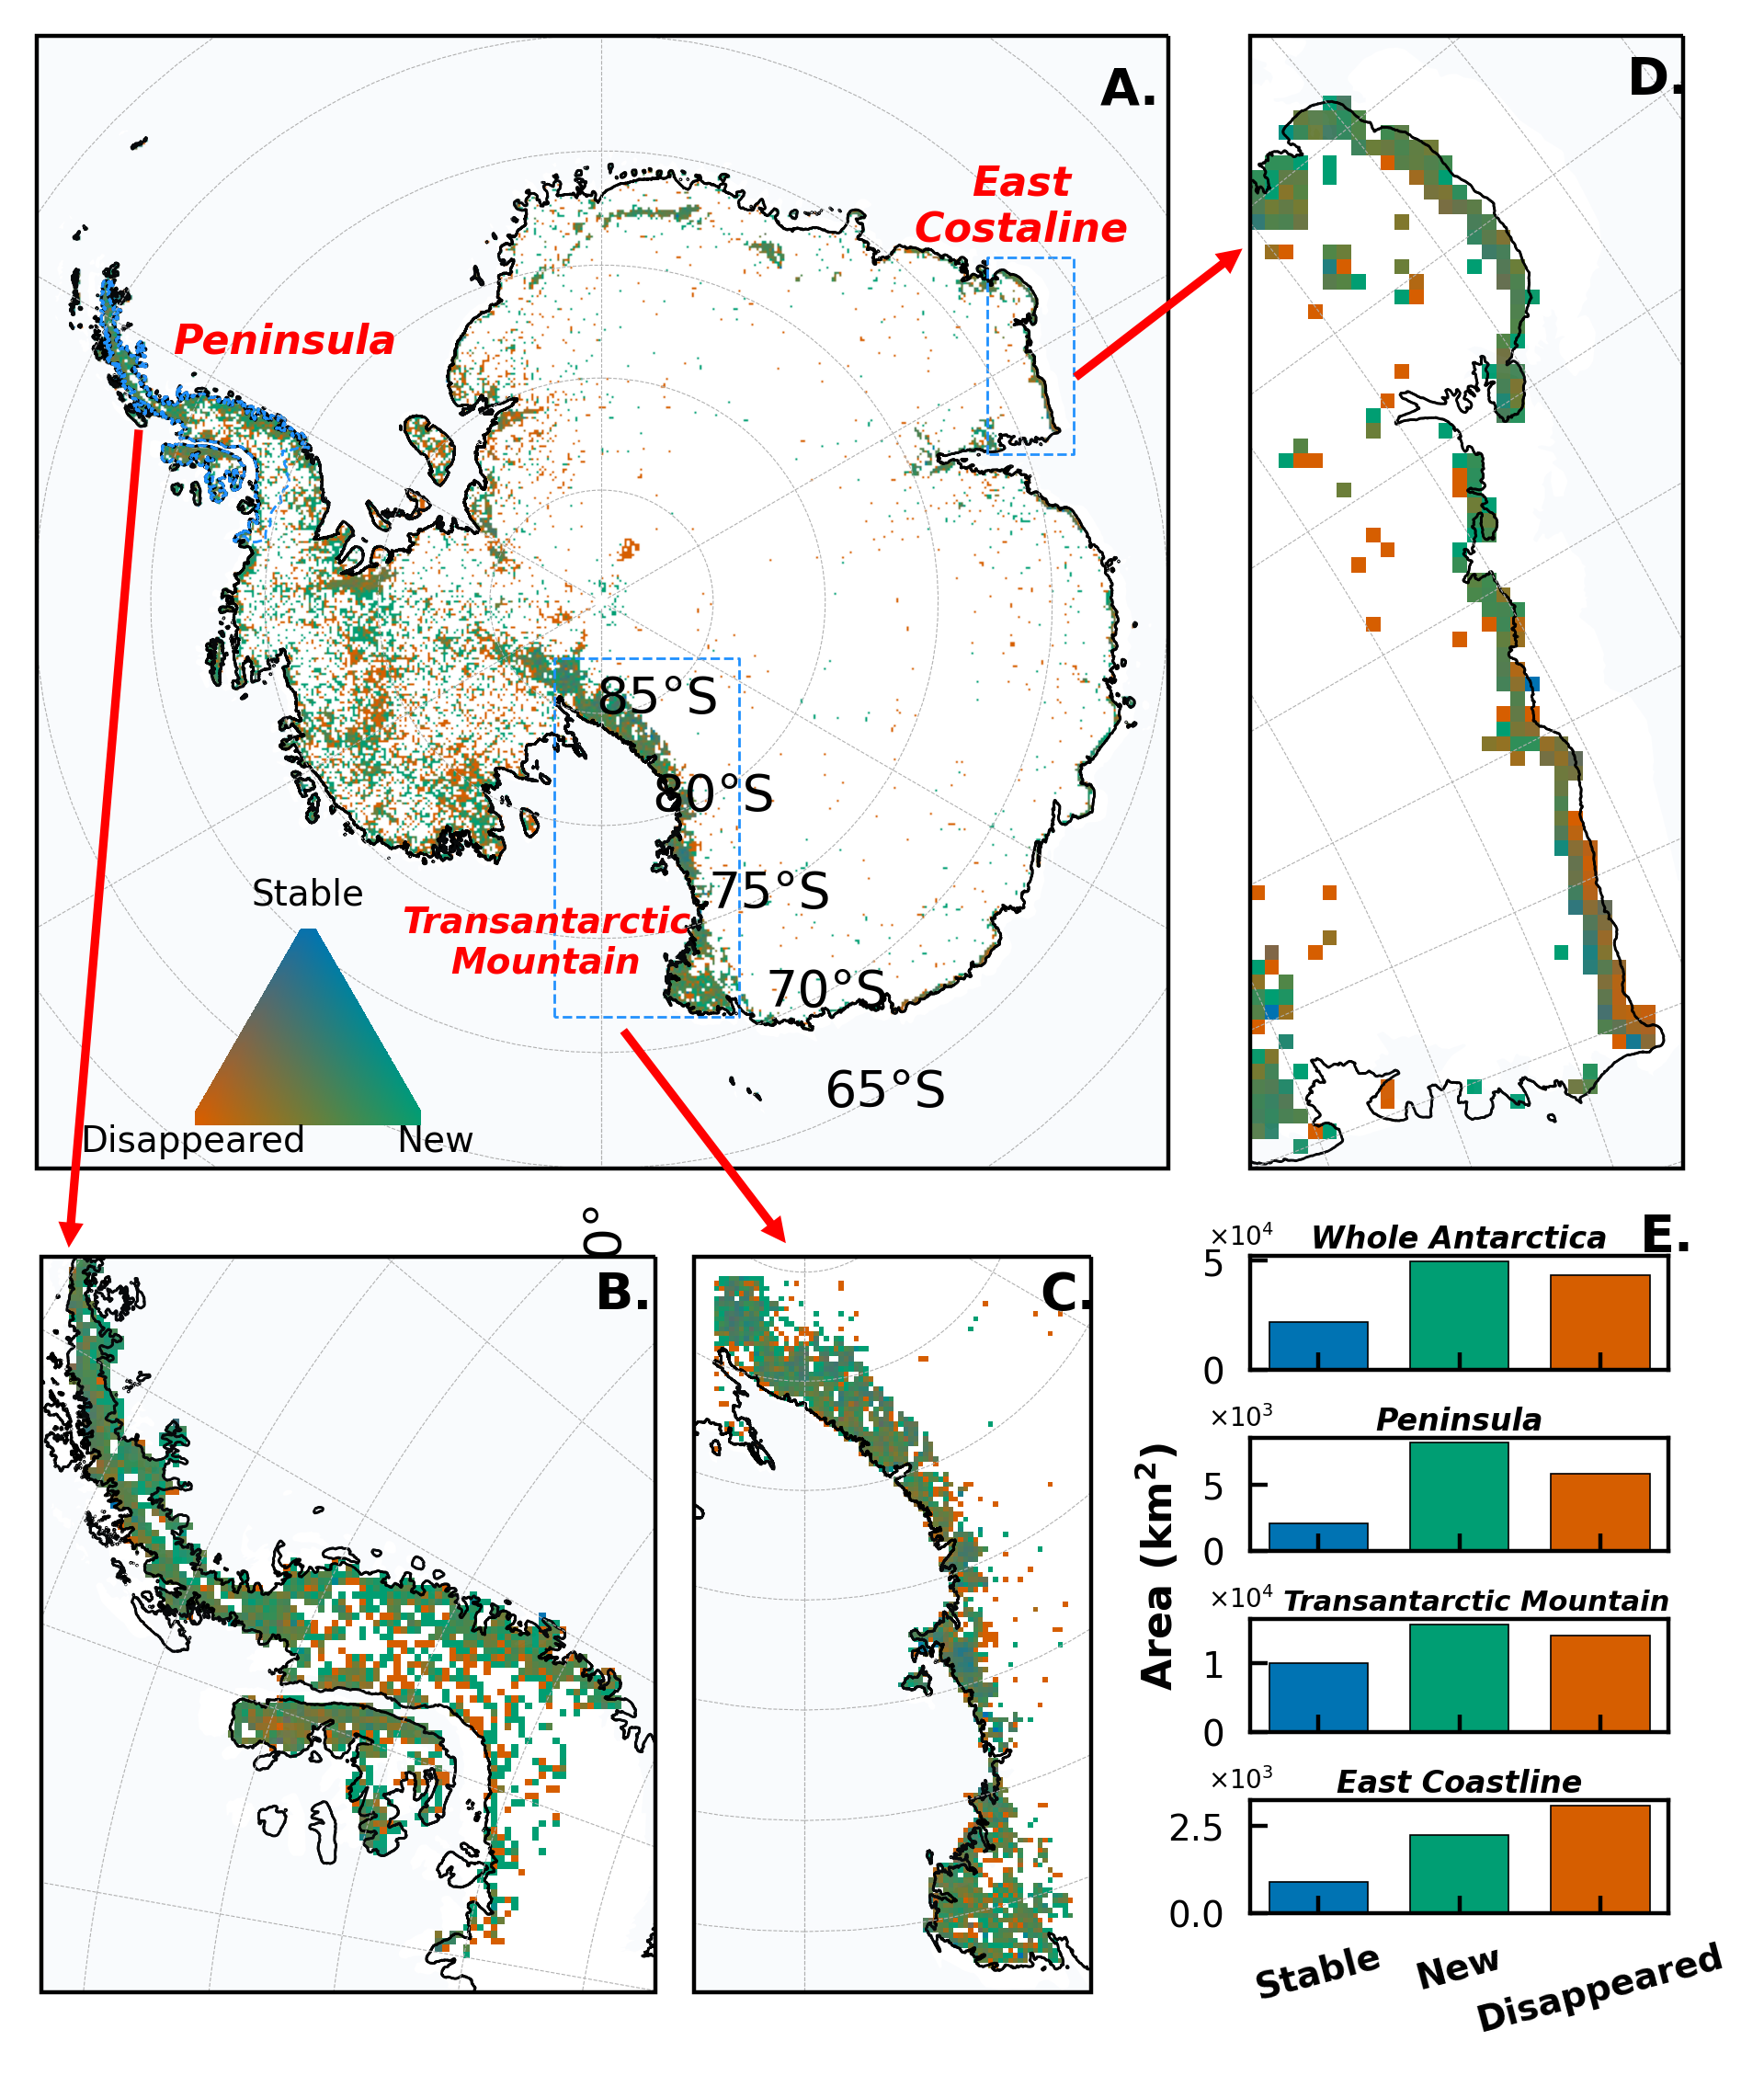

In [8]:
# Colorblind-friendly base colors (Okabe–Ito style)
C_STA = np.array([0.00, 0.45, 0.70])  # Stable (blue)      # #0072B2
C_NEW = np.array([0.00, 0.62, 0.45])  # New (bluish green) # #009E73
C_DIS = np.array([0.84, 0.37, 0.00])  # Disappeared (orange) # #D55E00

fig, ax = plt.subplots(figsize=(4,4), subplot_kw={'projection': ccrs.SouthPolarStereo()}, dpi = 400)

ax.set_extent([-180, 180, -90, -65], crs=ccrs.PlateCarree())
ax.add_feature(cf.OCEAN,alpha=0.05,zorder = 2)
gl = ax.gridlines(draw_labels=True, dms=True, linestyle='--',linewidth=0.2)
gl.top_labels = False
gl.right_labels = False

ax.imshow(rgba1, extent = [new_x_coords1.min(), new_x_coords1.max(), new_y_coords1.min(), new_y_coords1.max()],transform=ccrs.SouthPolarStereo())
shp.plot(ax = ax,transform=ccrs.SouthPolarStereo(),color = 'none',edgecolor="k",lw = 0.5)

central.plot(ax = ax,transform=ccrs.SouthPolarStereo(),color = 'none',edgecolor="dodgerblue",lw = 0.5, ls = "--")
west.plot(ax = ax,transform=ccrs.SouthPolarStereo(),color = 'none',edgecolor="dodgerblue",lw = 0.5, ls = "--")
pen.plot(ax = ax,transform=ccrs.SouthPolarStereo(),color = 'none',edgecolor="dodgerblue",lw =0.5, ls = "--")

ax.text(0.12,0.72, f'Peninsula', transform=ax.transAxes, fontsize = 8,fontweight='bold', fontstyle='italic',color = "red")
ax.text(0.45,0.2, f'Transantarctic\nMountain', transform=ax.transAxes, fontsize = 7,fontweight='bold', fontstyle='italic',color = "red", va='center',ha='center')
ax.text(0.87,0.85, f'East\nCostaline', transform=ax.transAxes, fontsize = 8,fontweight='bold', fontstyle='italic',color = "red", va='center',ha='center')
ax.text(0.94,0.94, f'A.', transform=ax.transAxes, fontsize = 10,fontweight='bold')


# === Ternary Color Legend (Inset Axes) ===
inset_ax = ax.inset_axes([0.14, 0.025, 0.2, 0.2])  # x, y, w, h (relative to main ax)
inset_ax.set_aspect('equal')
inset_ax.axis('off')

# === Colorblind-friendly ternary legend ===
res = 400
points = []
colors = []

for r in range(res + 1):            # r = Disappeared fraction count
    for g in range(res + 1 - r):     # g = New
        b = res - r - g              # b = Stable

        # Convert barycentric r,g,b to fractions
        p_dis = r / res
        p_new = g / res
        p_sta = b / res

        # Triangle coordinates
        x = 0.5 * (2 * g + b) / res
        y = (np.sqrt(3) / 2) * b / res

        # Mix the three Okabe–Ito base colors
        rgb = (
            p_dis * C_DIS +
            p_new * C_NEW +
            p_sta * C_STA
        )

        points.append((x, y))
        colors.append(rgb)

points = np.array(points)
colors = np.array(colors)
inset_ax.scatter(points[:, 0], points[:, 1], c=colors, s=4, marker='s', edgecolor='none')

inset_ax.text(-0.01, -0.07, 'Disappeared', ha='center', va='center', fontsize=7)
inset_ax.text(1.06, -0.07, 'New', ha='center', va='center', fontsize=7)
inset_ax.text(0.5, 1.02, 'Stable', ha='center', va='center', fontsize=7)

inset_ax.set_xlim(0, 1)
inset_ax.set_ylim(0, np.sqrt(3)/2)
inset_ax.set_xticks([])
inset_ax.set_yticks([])


##*********************************************************************#

left, bottom, width, height = 0.09,-0.45,0.5,0.5
ax2 = fig.add_axes([left,bottom,width,height],projection=ccrs.SouthPolarStereo())
ax2.set_extent([new_x_coords2.min()-50000, new_x_coords2.max()+50000, new_y_coords2.min()-50000,new_y_coords2.max()+5000], ccrs.SouthPolarStereo())

ax2.add_feature(cf.OCEAN,alpha=0.05,zorder = 2)
gl = ax2.gridlines(draw_labels=False, dms=True, linestyle='--',linewidth=0.2)
gl.top_labels = False
gl.right_labels = False

ax2.imshow(rgba2, extent = [new_x_coords2.min(), new_x_coords2.max(), new_y_coords2.min(), new_y_coords2.max()],transform=ccrs.SouthPolarStereo())
shp.plot(ax = ax2,transform=ccrs.SouthPolarStereo(),color = 'none',edgecolor="k",lw = 0.5)
ax2.text(0.9,0.93, f'B.', transform=ax2.transAxes, fontsize = 10,fontweight='bold')

##
left, bottom, width, height = 0.46,-0.45,0.5,0.5
ax3 = fig.add_axes([left,bottom,width,height],projection=ccrs.SouthPolarStereo())
ax3.set_extent([new_x_coords3.min()-50000, new_x_coords3.max()+50000, new_y_coords3.min()-50000,new_y_coords3.max()+50000], ccrs.SouthPolarStereo())
ax3.add_feature(cf.OCEAN,alpha=0.05,zorder = 2)
gl = ax3.gridlines(draw_labels=False, dms=True, linestyle='--',linewidth=0.2)
gl.top_labels = False
gl.right_labels = False

ax3.imshow(rgba3, extent = [new_x_coords3.min(), new_x_coords3.max(), new_y_coords3.min(), new_y_coords3.max()],transform=ccrs.SouthPolarStereo())
shp.plot(ax = ax3,transform=ccrs.SouthPolarStereo(),color = 'none',edgecolor="k",lw = 0.5)
ax3.text(0.87,0.93, f'C.', transform=ax3.transAxes, fontsize = 10,fontweight='bold')

###
left, bottom, width, height = 0.72,0.11,0.76,0.77
ax4 = fig.add_axes([left,bottom,width,height],projection=ccrs.SouthPolarStereo())
ax4.set_extent([new_x_coords4.min(), new_x_coords4.max()-50000, new_y_coords4.min(),new_y_coords4.max()], ccrs.SouthPolarStereo())

ax4.add_feature(cf.OCEAN,alpha=0.05,zorder = 2)
gl = ax4.gridlines(draw_labels=False, dms=True, linestyle='--',linewidth=0.2)
gl.top_labels = False
gl.right_labels = False

ax4.imshow(rgba4, extent = [new_x_coords4.min(), new_x_coords4.max(), new_y_coords4.min(), new_y_coords4.max()],transform=ccrs.SouthPolarStereo())
shp.plot(ax = ax4,transform=ccrs.SouthPolarStereo(),color = 'none',edgecolor="k",lw = 0.5)
ax4.text(0.87,0.95, f'D.', transform=ax4.transAxes, fontsize = 10,fontweight='bold')


### statistical barplot################################################################################################
a = np.sum(im_data1 == 1)*0.25
b = np.sum(im_data1 == 2)*0.25
c = np.sum(im_data1 == 3)*0.25

statis = pd.DataFrame(np.array([a,b,c]),columns = ["Values"])
statis["Category"] = ["Stable", "New", "Disappeared"]

axes = inset_axes(ax, width="37%", height="10%", loc='lower left', bbox_to_anchor=(1.05, -0.2, 1, 1),bbox_transform=ax.transAxes)
# axes.set_facecolor((0,0,0,0.1))

bar_colors = [
    C_STA,  # Stable
    C_NEW,  # New
    C_DIS   # Disappeared
]

axes.bar(statis['Category'], statis['Values'],
         width=0.7, color=bar_colors, edgecolor='k', linewidth=0.3)

axes.tick_params(axis='both',which='major',labelsize=7,direction='in',pad=5,bottom=True, left=True,top=False,right=False)
axes.set_xticklabels([])
axes.set_xlabel('')
axes.ticklabel_format(style='scientific', scilimits=(0, 0), axis='y')
axes.yaxis.offsetText.set_visible(False)
axes.text(-0.1,1.1, r"$\times 10^4$", transform=axes.transAxes, fontsize = 5)
axes.text(0.5,1.15, r"Whole Antarctica", transform=axes.transAxes, fontsize = 6, va='center',ha='center',fontweight='bold', fontstyle='italic')
axes.text(0.93,1.05, f'E.', transform=axes.transAxes, fontsize = 10,fontweight='bold')

a = np.sum(im_data2 == 1)*0.25
b = np.sum(im_data2 == 2)*0.25
c = np.sum(im_data2 == 3)*0.25
statis = pd.DataFrame(np.array([a,b,c]),columns = ["Values"])
statis["Category"] = ["Stable", "New", "Disappeared"]
axes1 = inset_axes(ax, width="37%", height="10%", loc='lower left', bbox_to_anchor=(1.05, -0.36, 1, 1),bbox_transform=ax.transAxes)
axes1.bar(statis['Category'], statis['Values'],
          width=0.7, color=bar_colors, edgecolor='k', linewidth=0.3)
axes1.tick_params(axis='both',which='major',labelsize=7,direction='in',pad=5,bottom=True, left=True,top=False,right=False)
axes1.set_xticklabels([])
axes1.set_xlabel('')
axes1.ticklabel_format(style='scientific', scilimits=(0, 0),axis='y')
axes1.yaxis.offsetText.set_visible(False)
axes1.text(-0.1,1.1, r"$\times 10^3$", transform=axes1.transAxes, fontsize = 5)
axes1.text(0.5,1.15, r"Peninsula", transform=axes1.transAxes, fontsize = 6, va='center',ha='center',fontweight='bold', fontstyle='italic')


a = np.sum(im_data3 == 1)*0.25
b = np.sum(im_data3 == 2)*0.25
c = np.sum(im_data3 == 3)*0.25
statis = pd.DataFrame(np.array([a,b,c]),columns = ["Values"])
statis["Category"] = ["Stable", "New", "Disappeared"]
axes2 = inset_axes(ax, width="37%", height="10%", loc='lower left', bbox_to_anchor=(1.05, -0.52, 1, 1),bbox_transform=ax.transAxes)
axes2.bar(statis['Category'], statis['Values'],
          width=0.7, color=bar_colors, edgecolor='k', linewidth=0.3)
axes2.tick_params(axis='both',which='major',labelsize=7,direction='in',pad=5,bottom=True, left=True,top=False,right=False)
axes2.set_xticklabels([])
axes2.set_xlabel('')
axes2.ticklabel_format(style='scientific', scilimits=(0, 0), axis='y')
axes2.yaxis.offsetText.set_visible(False)
axes2.text(-0.1,1.1, r"$\times 10^4$", transform=axes2.transAxes, fontsize = 5)
axes2.text(0.54,1.15, r"Transantarctic Mountain", transform=axes2.transAxes, fontsize = 5.5, va='center',ha='center',fontweight='bold', fontstyle='italic')

a = np.sum(im_data4 == 1)*0.25
b = np.sum(im_data4 == 2)*0.25
c = np.sum(im_data4 == 3)*0.25
statis = pd.DataFrame(np.array([a,b,c]),columns = ["Values"])
statis["Category"] = ["Stable", "New", "Disappeared"]
axes3 = inset_axes(ax, width="37%", height="10%", loc='lower left', bbox_to_anchor=(1.05, -0.68, 1, 1),bbox_transform=ax.transAxes)
axes3.bar(statis['Category'], statis['Values'],
          width=0.7, color=bar_colors, edgecolor='k', linewidth=0.3)
axes3.tick_params(axis='both',which='major',labelsize=7,direction='in',pad=5,bottom=True, left=True,top=False,right=False)
axes3.ticklabel_format(style='scientific', scilimits=(0, 0), axis='y')
for tick in axes3.get_xticklabels():
    tick.set_rotation(15)
    tick.set_fontweight("bold")
axes3.yaxis.offsetText.set_visible(False)
axes3.text(-0.1,1.1, r"$\times 10^3$", transform=axes3.transAxes, fontsize = 5)
axes3.text(0.5,1.15, r"East Coastline", transform=axes3.transAxes, fontsize = 6, va='center',ha='center',fontweight='bold', fontstyle='italic')

fig.text(0.89, -0.16, r'Area ($\mathbf{km^2}$)',fontsize=8,fontweight='bold',rotation=90, va='center',ha='center')
ax.arrow(0.09, 0.65, -0.06, -0.7, transform=ax.transAxes, color='red',width=0.003, head_width=0.015, head_length=0.015, clip_on=False, zorder = 5)
ax.arrow(0.52, 0.12, 0.13, -0.17, transform=ax.transAxes, color='red',width=0.003, head_width=0.015, head_length=0.015, clip_on=False, zorder = 5)
ax.arrow(0.92, 0.7, 0.13, 0.1, transform=ax.transAxes, color='red',width=0.003, head_width=0.015, head_length=0.015, clip_on=False, zorder = 5)
plt.savefig(r'C:\Users\hyou34\OneDrive - UW-Madison\manuscripts\paper\Greening Antarctica\nature_version\R1_Nature\Supplementary_Information\High_Resolution_Figures\Figure_2_New_Greenness_Dynamics.png', dpi=500, bbox_inches='tight') 


## Figure 3

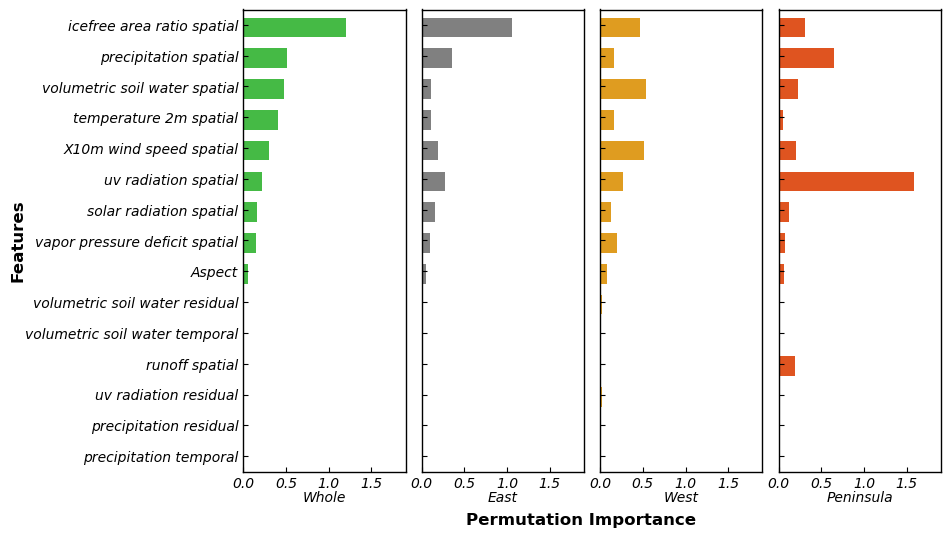

In [9]:
data_path = "/Users/jifujiang/Desktop/Antarctic_greenning_mapping/1_data/permutation_importance/"
file_name1 = "Continent_permutation_importance.csv"
file_name2 = "East_permutation_importance.csv"
file_name3 = "West_permutation_importance.csv"
file_name4 = "Peninsula_permutation_importance.csv"

df1 = pd.read_csv(f"{data_path}{file_name1}")
df2 = pd.read_csv(f"{data_path}{file_name2}")
df3 = pd.read_csv(f"{data_path}{file_name3}")
df4 = pd.read_csv(f"{data_path}{file_name4}")

df1.drop(["Importance_STD"], axis = 1, inplace = True)
df2.drop(["Importance_STD"], axis = 1, inplace = True)
df3.drop(["Importance_STD"], axis = 1, inplace = True)
df4.drop(["Importance_STD"], axis = 1, inplace = True)

df1.columns = ["Feature", "Importance_Whole"]
df2.columns = ["Feature", "Importance_East"]
df3.columns = ["Feature", "Importance_West"]
df4.columns = ["Feature", "Importance_Peninsula"]

df = df1.merge(df2, on="Feature", how="inner").merge(df3, on="Feature", how="inner").merge(df4, on="Feature", how="inner")

df.sort_values(by="Importance_Whole", ascending=False, inplace = True)
df.reset_index(drop = True, inplace = True)
df["Feature"] = df["Feature"].str.replace("_", " ")

idx = 15
df = df.iloc[:idx,:]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1,4, figsize=(9, 6), dpi=100)
plt.subplots_adjust(wspace = 0.1)


locs = ["Whole", "East", "West", "Peninsula"]
colors = ["limegreen", "gray", "orange", "orangered"]

axes = [ax1, ax2, ax3, ax4]
for idx, ax in enumerate(axes):
    ax.spines[['bottom','left','top','right']].set_linewidth(1)
    sns.barplot(x=f"Importance_{locs[idx]}", y="Feature", data=df, ax = ax, linewidth = 0.5, color = colors[idx])
    for patch in ax.patches:
        current_height = patch.get_height()
        patch.set_height(current_height * 0.8)  # shrink to 60% thickness
        patch.set_y(patch.get_y() + current_height * 0.2)
    
    ax.set_xlabel(locs[idx], fontsize=10, labelpad = 0.05, fontstyle = "italic")
    ax.set_ylabel('Features', fontsize=12, labelpad = 0.05,fontweight='bold')
    ax.tick_params(labelsize=10,direction='in')
    ax.set_xlim(0,1.9)
    ax.set_xticks(np.arange(0, 2.0, 0.5))
    for label in ax.get_xticklabels() + ax.get_yticklabels():
#         label.set_fontweight('bold')
        label.set_fontstyle('italic')

    
    if idx !=0:
        ax.set_yticklabels([])
        ax.set_ylabel('')     
fig.text(0.5, 0.03, 'Permutation Importance',fontsize=12,fontweight='bold', va='center',ha='center')
plt.savefig('/Users/jifujiang/Desktop/Antarctic_greenning_mapping/2_exported_figures/Figure_3 Permutation importance1_new.png', dpi=500, bbox_inches='tight') 


## Figure 4

In [5]:
def process_df(df):
    new_var = []
    for variables in df["variables"]:
        variable_list = [var.strip().replace('_', ' ') for var in variables.split(',')]
        new_var.append(variable_list)
    df["variables"] = new_var
    df = df[["variables", "Trend p-value", "Trend is Significant"]]
    return df

def sort_df_by_reference(df, order_mapping):
    df["sort_key"] = df["variables"].apply(lambda x: order_mapping.get(tuple(x), float('inf')))
    df_sorted = df.sort_values("sort_key").drop(columns="sort_key").reset_index(drop=True)
    return df_sorted

def value_extract(boolean_index_data, col1, col2):
    values = [item[col1] for item in boolean_index_data]
    symbols = [item[col2] for item in boolean_index_data]
    values = pd.DataFrame([values,symbols]).T
    values.columns = ["values","symbols"]
    values["idx"] = [x for x in range(0, len(values))]
    return values

In [6]:
data_path = r"G:\Hangkai\Anttarctic Vegetation Dynamic\1_data"

df1 = pd.read_csv(f"{data_path}\\detrend_mk_pvalues_avg_std.csv")
df2 = pd.read_csv(f"{data_path}\\detrend_mk_pvalues_avg_std_East.csv")
df3 = pd.read_csv(f"{data_path}\\detrend_mk_pvalues_avg_std_West.csv")
df4 = pd.read_csv(f"{data_path}\\detrend_mk_pvalues_avg_std_Peninsula.csv")

df1['Significant'] = (df1['mean_p_value'] < 0.05)
df2['Significant'] = (df2['Mean_p_value'] < 0.05)
df3['Significant'] = (df3['Mean_p_value'] < 0.05)
df4['Significant'] = (df4['Mean_p_value'] < 0.05)

df1 = df1[["variables", "mean_p_value", "Significant"]]
df2 = df2[["Variables", "Mean_p_value", "Significant"]]
df3 = df3[["Variables", "Mean_p_value", "Significant"]]
df4 = df4[["Variables", "Mean_p_value", "Significant"]]

df1.columns = ["variables", "Trend p-value", "Trend is Significant"]
df2.columns = ["variables", "Trend p-value", "Trend is Significant"]
df3.columns = ["variables", "Trend p-value", "Trend is Significant"]
df4.columns = ["variables", "Trend p-value", "Trend is Significant"]



df1 = process_df(df1)
df2 = process_df(df2)
df3 = process_df(df3)
df4 = process_df(df4)

order_mapping = {tuple(v): i for i, v in enumerate(sorted(df1["variables"], key=len))}

df1 = sort_df_by_reference(df1, order_mapping)
df2 = sort_df_by_reference(df2, order_mapping)
df3 = sort_df_by_reference(df3, order_mapping)
df4 = sort_df_by_reference(df4, order_mapping)

groups = list(df1["variables"])[-1]

boolean_index_data = []
for combination,value1,symbol1,value2,symbol2,value3,symbol3,value4,symbol4 in zip(df1["variables"],df1["Trend p-value"],df1["Trend is Significant"],df2["Trend p-value"],df2["Trend is Significant"],df3["Trend p-value"],df3["Trend is Significant"],df4["Trend p-value"],df4["Trend is Significant"]):
    row = [group in combination for group in groups]
    boolean_index_data.append((row,value1,symbol1,value2,symbol2,value3,symbol3,value4,symbol4))

index = pd.MultiIndex.from_tuples([item[0] for item in boolean_index_data], names=groups)
values1 = value_extract(boolean_index_data, 1, 2)
values2 = value_extract(boolean_index_data, 3, 4)
values3 = value_extract(boolean_index_data, 5, 6)
values4 = value_extract(boolean_index_data, 7, 8)

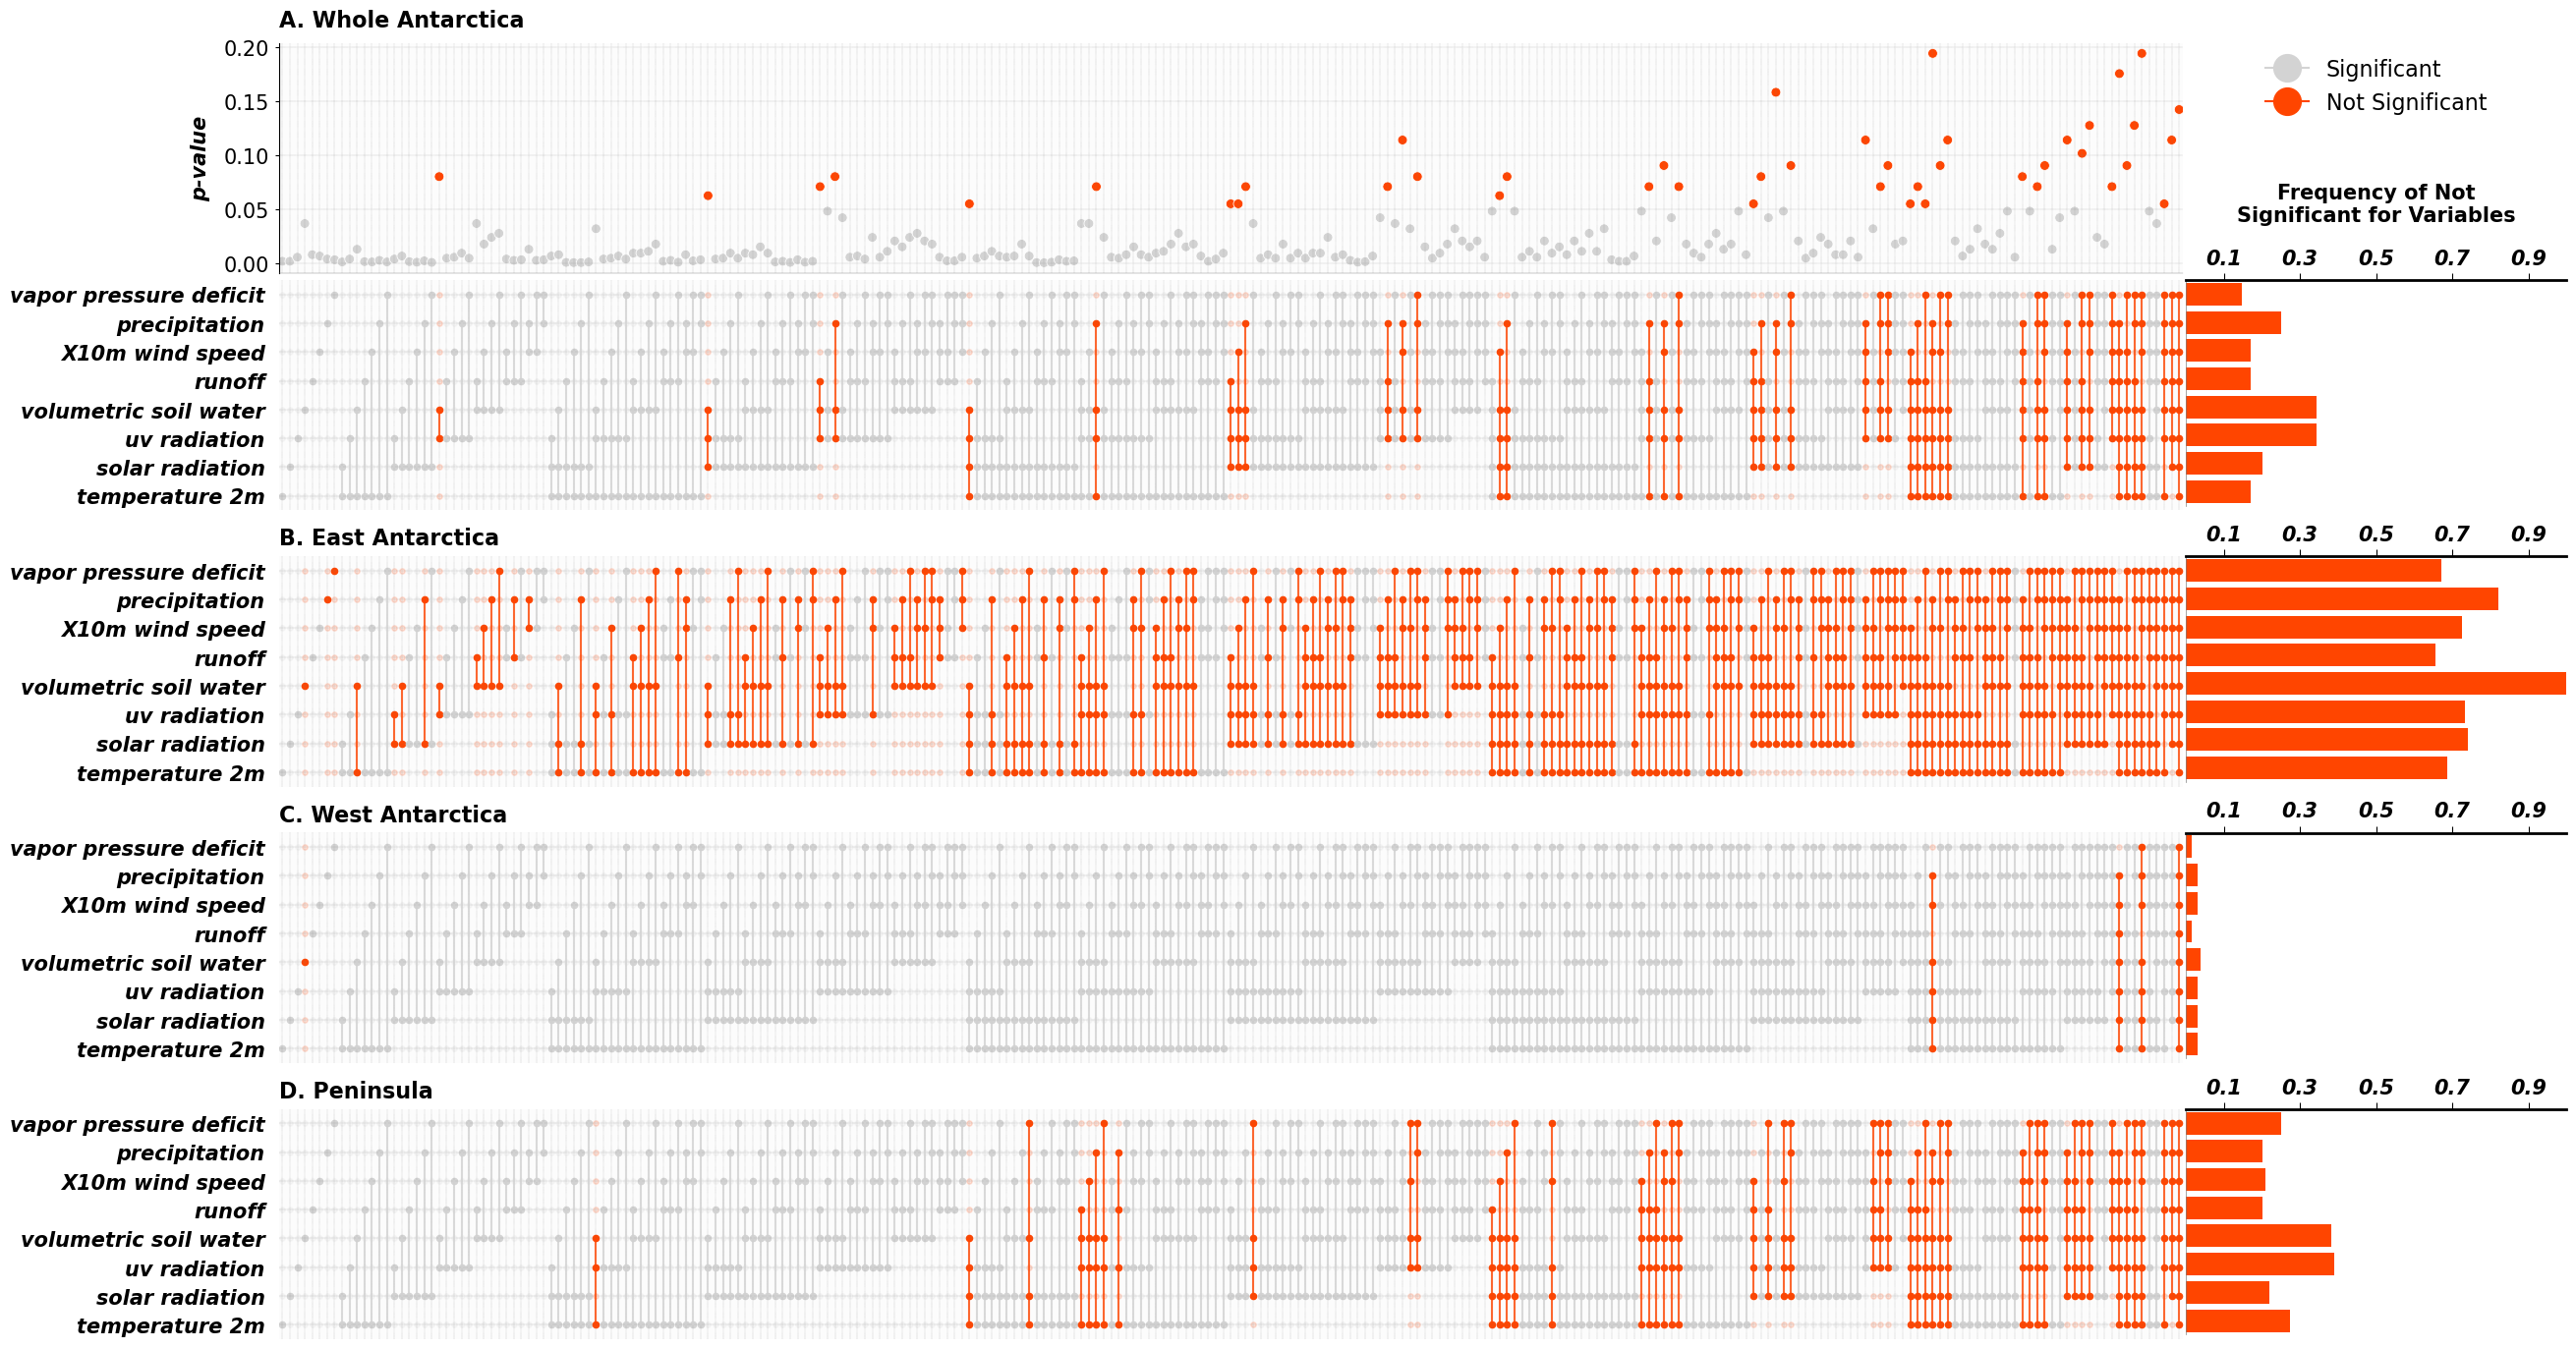

In [8]:
fig,(ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize = (25,14))

axes = [ax1, ax2, ax3, ax4]
values = [values1, values2, values3, values4]
text = ["A. Whole Antarctica", "B. East Antarctica", "C. West Antarctica", "D. Peninsula"]

for idx, ax in enumerate(axes):
    value = values[idx]

    ax.set_facecolor((0,0,0,0.01))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.grid(color='gray', linestyle=':', linewidth=0.3)
    
    if idx == 0:
        ax_inset = inset_axes(ax, width="100%", height="100%", bbox_to_anchor=(0, 1, 1, 1),loc='lower center' ,bbox_transform=ax.transAxes)
        ax_inset.set_facecolor((0,0,0,0.01))
        ax_inset.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax_inset.grid(color='gray', linestyle=':', linewidth=0.3)
        
        sns.scatterplot(x = "idx", y = "values", hue = "symbols", data = value,style="symbols",markers={True: "o", False: "o"}, 
                palette=["orangered", "lightgray"],s = 50)
        ax_inset.set_xlim(value["idx"].min()-0.5, values1["idx"].max()+0.5)

        ax_inset.spines[['top', 'right']].set_visible(False)
        ax_inset.spines[['bottom']].set_color("gray")
        ax_inset.spines['bottom'].set_linewidth(0.3)
        ax_inset.set_xlabel('')
        ax_inset.tick_params(axis='both', which='major', direction='out', length=3, labelsize=15, 
                   bottom = False, top = False, left = True, right = False,
                   labelbottom = False, labeltop = False, labelleft = True, labelright = False)
        ax_inset.set_ylabel("p-value",labelpad = 10, fontweight='bold',fontstyle='italic',fontsize=15)
        ax_inset.legend_.remove()


    dd = pd.DataFrame(index.tolist(), columns=index.names).astype(int)
    for i in range(len(dd)): 
        color = "lightgray" if value[value["idx"] == i]["symbols"].values[0] else "orangered"
        for j in range(dd.shape[1]):
            if dd.iloc[i, j]:
                ax.scatter(i, j, color=color, s=20, alpha=1)
            else:
                ax.scatter(i, j, color=color, s=15, alpha=0.15)
                
    for i in range(len(dd)):
        color = "lightgray" if value[value["idx"] == i]["symbols"].values[0] else "orangered"
        active_indices = np.where(dd.iloc[i].values == 1)[0] 
        if len(active_indices) > 1:
            ax.plot([i] * len(active_indices), active_indices, color=color, linewidth=1.5, alpha = 0.8)
    
    
    frequency_false = []
    frequency_true = []
    df = pd.concat([value, dd], axis = 1)
    for col in dd.columns:
        df_filter = df[["symbols", col]]
        df_filter = df_filter[df_filter[col] == 1]

        total = df_filter.shape[0]
        false_count = (df_filter["symbols"] == False).sum()
        false_ratio = false_count / total

        true_count = (df_filter["symbols"] == True).sum()
        true_ratio = true_count / total

        frequency_false.append(false_ratio)
        frequency_true.append(true_ratio)
    
    ax_side = inset_axes(ax, width="20%", height="98%", bbox_to_anchor=(0.205, -0.01, 1, 1),loc='lower right' ,bbox_transform=ax.transAxes)
    ax_side.barh(np.arange(len(dd.columns)), frequency_false, color = "orangered")
    ax_side.set_ylim(-0.5, len(dd.columns) - 0.5)
    ax_side.tick_params(axis='both', which='major', direction='out', length=5, labelsize=15, 
                   bottom = False, top = True, left = True, right = False,
                   labelbottom = False, labeltop = True, labelleft = True, labelright = False)
    ax_side.tick_params(axis='y', which='major', direction='out', length=0)
    
    ax_side.spines[['bottom', 'right']].set_visible(False)
    ax_side.spines[['left']].set_color("gray")
    ax_side.spines[['left']].set_linewidth(0.5)
    ax_side.spines[['top']].set_linewidth(2)
    ax_side.set_yticklabels([])
    ax_side.set_xlim(0,1)
    
    xticks = np.arange(0.1, 1.1, 0.2)
    labels = [f"{v:.1f}" for v in xticks]

    ax_side.set_xticks(xticks)
    ax_side.set_xticklabels(labels, fontweight='bold', style='italic', fontsize = 15)
    ax_side.xaxis.set_label_position('top')
    ax_side.set_xlabel("Frequency of Not\nSignificant for Variables", fontsize=15, labelpad = 20, fontweight='bold')
#     ax_side.set_xticklabels([]) if idx !=0 else None
    ax_side.set_xlabel('') if idx !=0 else None

    #############################################################################################3
    ax.set_xlim(value["idx"].min()-0.5, value["idx"].max()+0.5)
    ax.set_yticks(range(len(dd.columns)))
    ax.set_yticklabels(dd.columns, fontweight='bold',fontstyle='italic',fontsize=15)
    ax.set_ylim(-0.5, len(dd.columns) - 0.5)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.tick_params(axis='both', which='major', direction='out', length=0, labelsize=15,pad = 0,
                   bottom = False, top = False, left = True, right = False,
                   labelbottom = False, labeltop = False, labelleft = True, labelright = False)
    ax.tick_params(axis='y', pad=10)
    y_loc = 2.1 if idx ==0 else 1.05
    ax.text(0,y_loc, f'{text[idx]}', transform=ax.transAxes, fontsize = 16, fontweight='bold')
    
    if idx == 0:
#         colors = ["limegreen", "dodgerblue"]
#         colors = ["limegreen", "orangered"]
        colors = ["lightgray", "orangered"]
        handles = []
        labels = ["Significant", "Not Significant"]
        for i in range(2):
            handle = Line2D([0], [0], marker="o", color=colors[i], label=labels[i],
                            markerfacecolor=colors[i], markersize=20)
            handles.append(handle)

        ax.legend(handles, labels, loc='upper right',fontsize = 16,frameon = 'none',bbox_to_anchor=(1.17, 2.05),
                  facecolor = 'none',edgecolor = 'none',ncol = 1, columnspacing=2)
plt.savefig(r'C:\Users\hyou34\OneDrive - UW-Madison\manuscripts\paper\Greening Antarctica\nature_version\R1_Nature\Supplementary_Information\High_Resolution_Figures\Figure_4 Significace for different variables combination3_new.png', dpi=1000, bbox_inches='tight') 
plt.show()

## Plot for AGU Poster

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker
import seaborn as sns

# -------------------- 1. Helper functions -------------------- #
def process_df(df):
    """Split the variables string into a list and keep only needed cols."""
    new_var = []
    for variables in df["variables"]:
        variable_list = [var.strip().replace('_', ' ') for var in variables.split(',')]
        new_var.append(variable_list)
    df["variables"] = new_var
    df = df[["variables", "Trend p-value", "Trend is Significant"]]
    return df

def sort_df_by_reference(df, order_mapping):
    """Sort df according to a reference order of variable combinations."""
    df["sort_key"] = df["variables"].apply(lambda x: order_mapping.get(tuple(x), float('inf')))
    df_sorted = df.sort_values("sort_key").drop(columns="sort_key").reset_index(drop=True)
    return df_sorted

# -------------------- 2. Read and prepare data -------------------- #
data_path = r"G:\Hangkai\Anttarctic Vegetation Dynamic\1_data"

df1 = pd.read_csv(f"{data_path}\\detrend_mk_pvalues_avg_std.csv")
df1['Significant'] = (df1['mean_p_value'] < 0.05)

df1 = df1[["variables", "mean_p_value", "Significant"]]
df1.columns = ["variables", "Trend p-value", "Trend is Significant"]

df1 = process_df(df1)

# Use df1 ordering as reference
order_mapping = {tuple(v): i for i, v in enumerate(sorted(df1["variables"], key=len))}
df1 = sort_df_by_reference(df1, order_mapping)

# groups = list of all single variables (taken from the longest combo)
groups = list(df1["variables"])[-1]

# Build boolean index (which variables are in each combination)
boolean_index_data = []
for combination, pval, sig in zip(df1["variables"],
                                  df1["Trend p-value"],
                                  df1["Trend is Significant"]):
    row = [group in combination for group in groups]
    boolean_index_data.append((row, pval, sig))

index = pd.MultiIndex.from_tuples([item[0] for item in boolean_index_data], names=groups)

values = pd.DataFrame({
    "values": [item[1] for item in boolean_index_data],
    "symbols": [item[2] for item in boolean_index_data],
})
values["idx"] = np.arange(len(values))

dd = pd.DataFrame(index.tolist(), columns=index.names).astype(int)

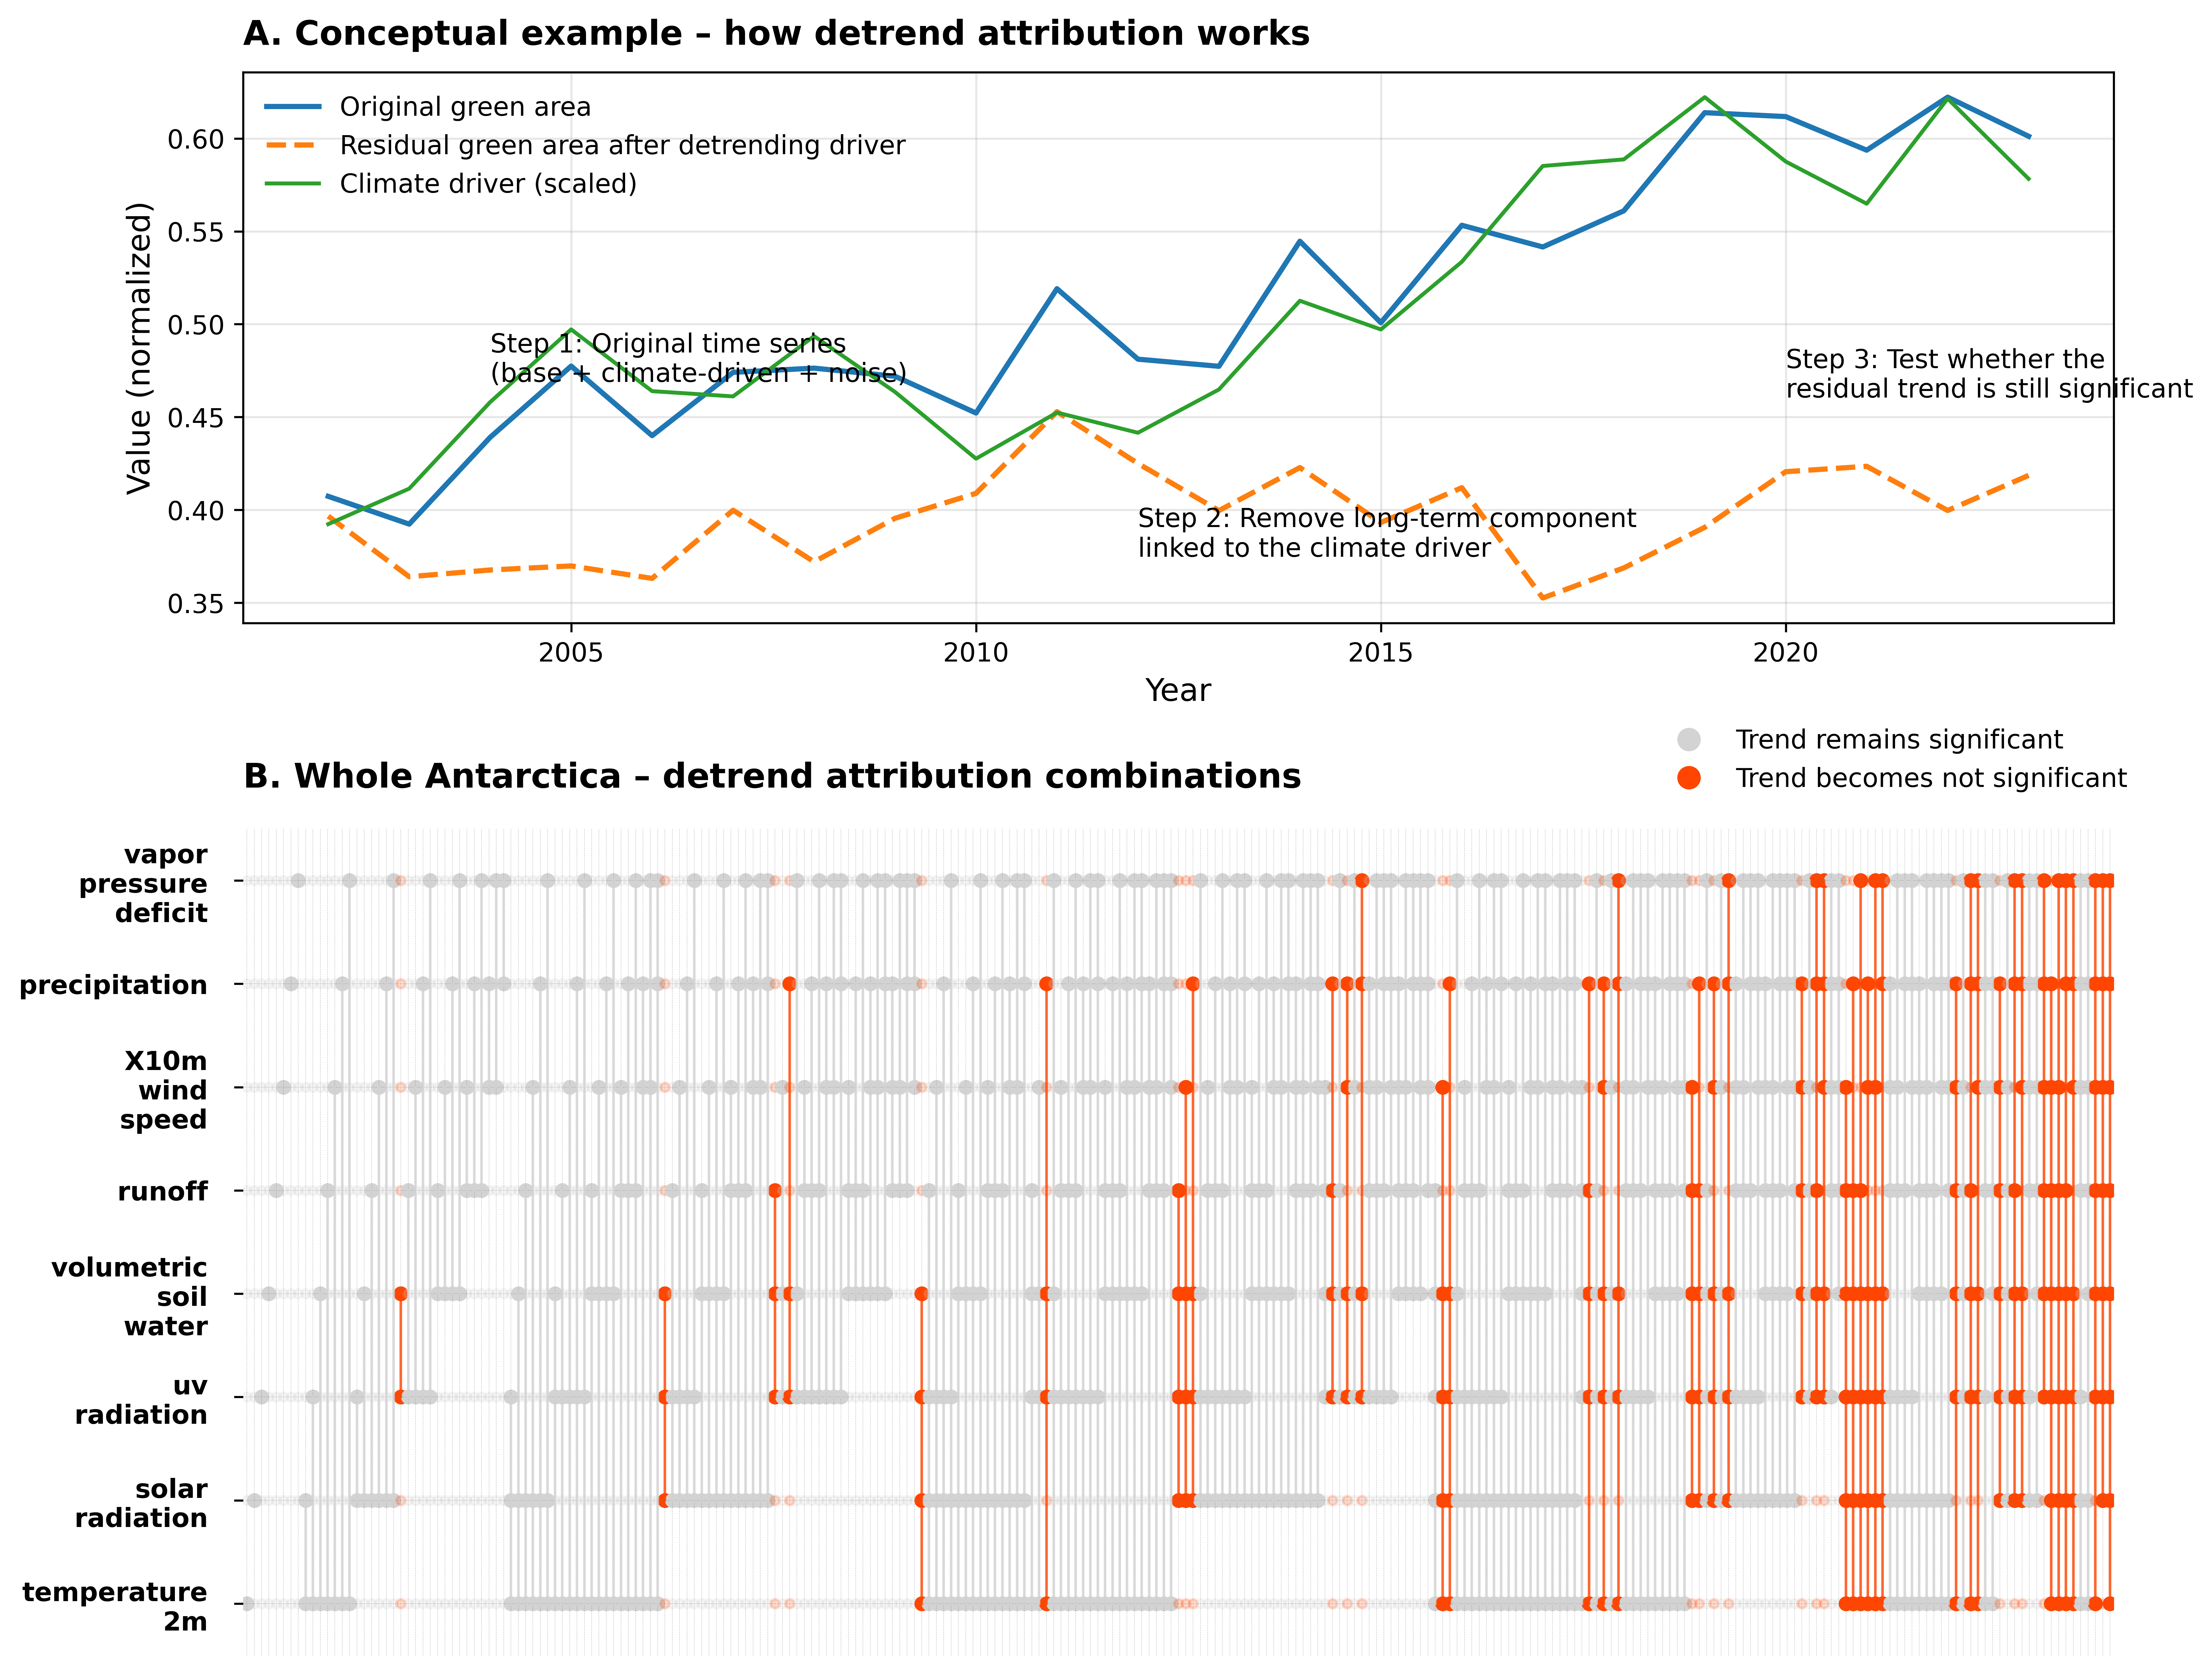

In [15]:
# -------------------- 3. Create figure: panel A = mechanism, panel B = matrix -------------------- #
fig, (ax_mech, ax_matrix) = plt.subplots(
    2, 1, figsize=(12, 9),
    gridspec_kw={"height_ratios": [2, 3]}, dpi = 600
)

# ==================== Panel A: Conceptual mechanism of detrend attribution ==================== #
axA = ax_mech

# Years
years = np.arange(2002, 2024)
t = years - years[0]

# ------------------------------
# 1. Climate driver with noise + decadal trend
# ------------------------------
np.random.seed(42)  # consistent results
driver = (t * 0.05) + 0.2 * np.sin(t / 2) + 0.1 * np.random.randn(len(t))
# long-term upward + interannual variability + noise

# ------------------------------
# 2. Baseline green-area trend (slow increase)
# ------------------------------
baseline = 0.4 + 0.005 * t

# ------------------------------
# 3. Driver-driven green-area trend
# ------------------------------
driver_effect = 0.12 * driver   # climate driver influence

# ------------------------------
# 4. Total original green area: base + driver influence + small noise
# ------------------------------
green_original = baseline + driver_effect + 0.02 * np.random.randn(len(t))

# ------------------------------
# 5. Detrend: remove driver-driven component (linear regression)
# ------------------------------
X = np.vstack([np.ones(len(driver)), driver]).T
beta = np.linalg.lstsq(X, green_original, rcond=None)[0]
green_resid = green_original - (X @ beta - beta[0])  # remove driver contribution

# ------------------------------
# 6. Plot
# ------------------------------
axA.plot(years, green_original, label="Original green area", linewidth=2)
axA.plot(years, green_resid, linestyle='--',
         label="Residual green area after detrending driver", linewidth=2)
axA.plot(years,
         (driver - driver.min()) / (driver.max() - driver.min()) * 
         (green_original.max() - green_original.min()) + green_original.min(),
         label="Climate driver (scaled)", linewidth=1.5)

axA.set_xlabel("Year", fontsize=12)
axA.set_ylabel("Value (normalized)", fontsize=12)
axA.text(
    0, 1.05,
    'A. Conceptual example – how detrend attribution works',
    transform=axA.transAxes,
    fontsize=13, fontweight='bold'
)
axA.grid(alpha=0.3)
axA.legend(fontsize=10, frameon=False, loc="upper left")

# ------------------------------
# 7. Annotations for steps
# ------------------------------
axA.text(years[2], green_original[2] + 0.03,
         "Step 1: Original time series\n(base + climate-driven + noise)",
         fontsize=10)

axA.text(years[10], green_resid[10] - 0.05,
         "Step 2: Remove long-term component\nlinked to the climate driver",
         fontsize=10)

axA.text(years[18], green_resid[18] + 0.04,
         "Step 3: Test whether the\nresidual trend is still significant",
         fontsize=10)

# ==================== Panel B: Whole-continent detrend attribution combinations ==================== #
axB = ax_matrix

axB.set_facecolor((0, 0, 0, 0.00))
axB.xaxis.set_major_locator(ticker.MultipleLocator(1))
axB.grid(color='gray', linestyle=':', linewidth=0.25, alpha=0.6)

# ------- Main Matrix (no p-value inset now) ------- #
for i in range(len(dd)):
    sig = values.loc[i, "symbols"]           # True = significant, False = not significant
    color = "lightgray" if sig else "orangered"
    for j in range(dd.shape[1]):
        s = 22 if dd.iloc[i, j] else 12      # bigger dot if variable in combination
        alpha = 1 if dd.iloc[i, j] else 0.18
        axB.scatter(i, j, color=color, s=s, alpha=alpha)

# Connect active variables within each combination
for i in range(len(dd)):
    sig = values.loc[i, "symbols"]
    color = "lightgray" if sig else "orangered"
    active = np.where(dd.iloc[i].values == 1)[0]
    if len(active) > 1:
        axB.plot([i] * len(active), active, color=color, linewidth=1, alpha=0.8)

# ---------------- Axis and Labels ---------------- #
axB.set_xlim(values["idx"].min() - 0.5, values["idx"].max() + 0.5)
axB.set_ylim(-0.5, len(dd.columns) - 0.5)
axB.set_yticks(range(len(dd.columns)))

# Allow long variable names to breathe
labels = [label.replace(" ", "\n") for label in dd.columns]
axB.set_yticklabels(labels, fontsize=10, fontweight="bold")

axB.spines[['top','right','left','bottom']].set_visible(False)
axB.tick_params(axis='x', labelbottom=False, bottom=False)
axB.tick_params(axis='y', pad=10)

#axB.set_ylabel("Variables in combination", fontsize=12, labelpad=30)

# --- Title for panel B --- #
axB.text(
    0, 1.05,
    'B. Whole Antarctica – detrend attribution combinations',
    transform=axB.transAxes,
    fontsize=13, fontweight='bold'
)

# --- Legend --- #
handles = [
    Line2D([0],[0], marker="o", color="lightgray", markersize=8, linestyle='None',
           markerfacecolor="lightgray", label="Trend remains significant"),
    Line2D([0],[0], marker="o", color="orangered", markersize=8, linestyle='None',
           markerfacecolor="orangered", label="Trend becomes not significant")
]

axB.legend(handles,
           ["Trend remains significant", "Trend becomes not significant"],
           loc='upper right', fontsize=10, frameon=False,
           bbox_to_anchor=(1.02, 1.15))

plt.tight_layout()
plt.show()

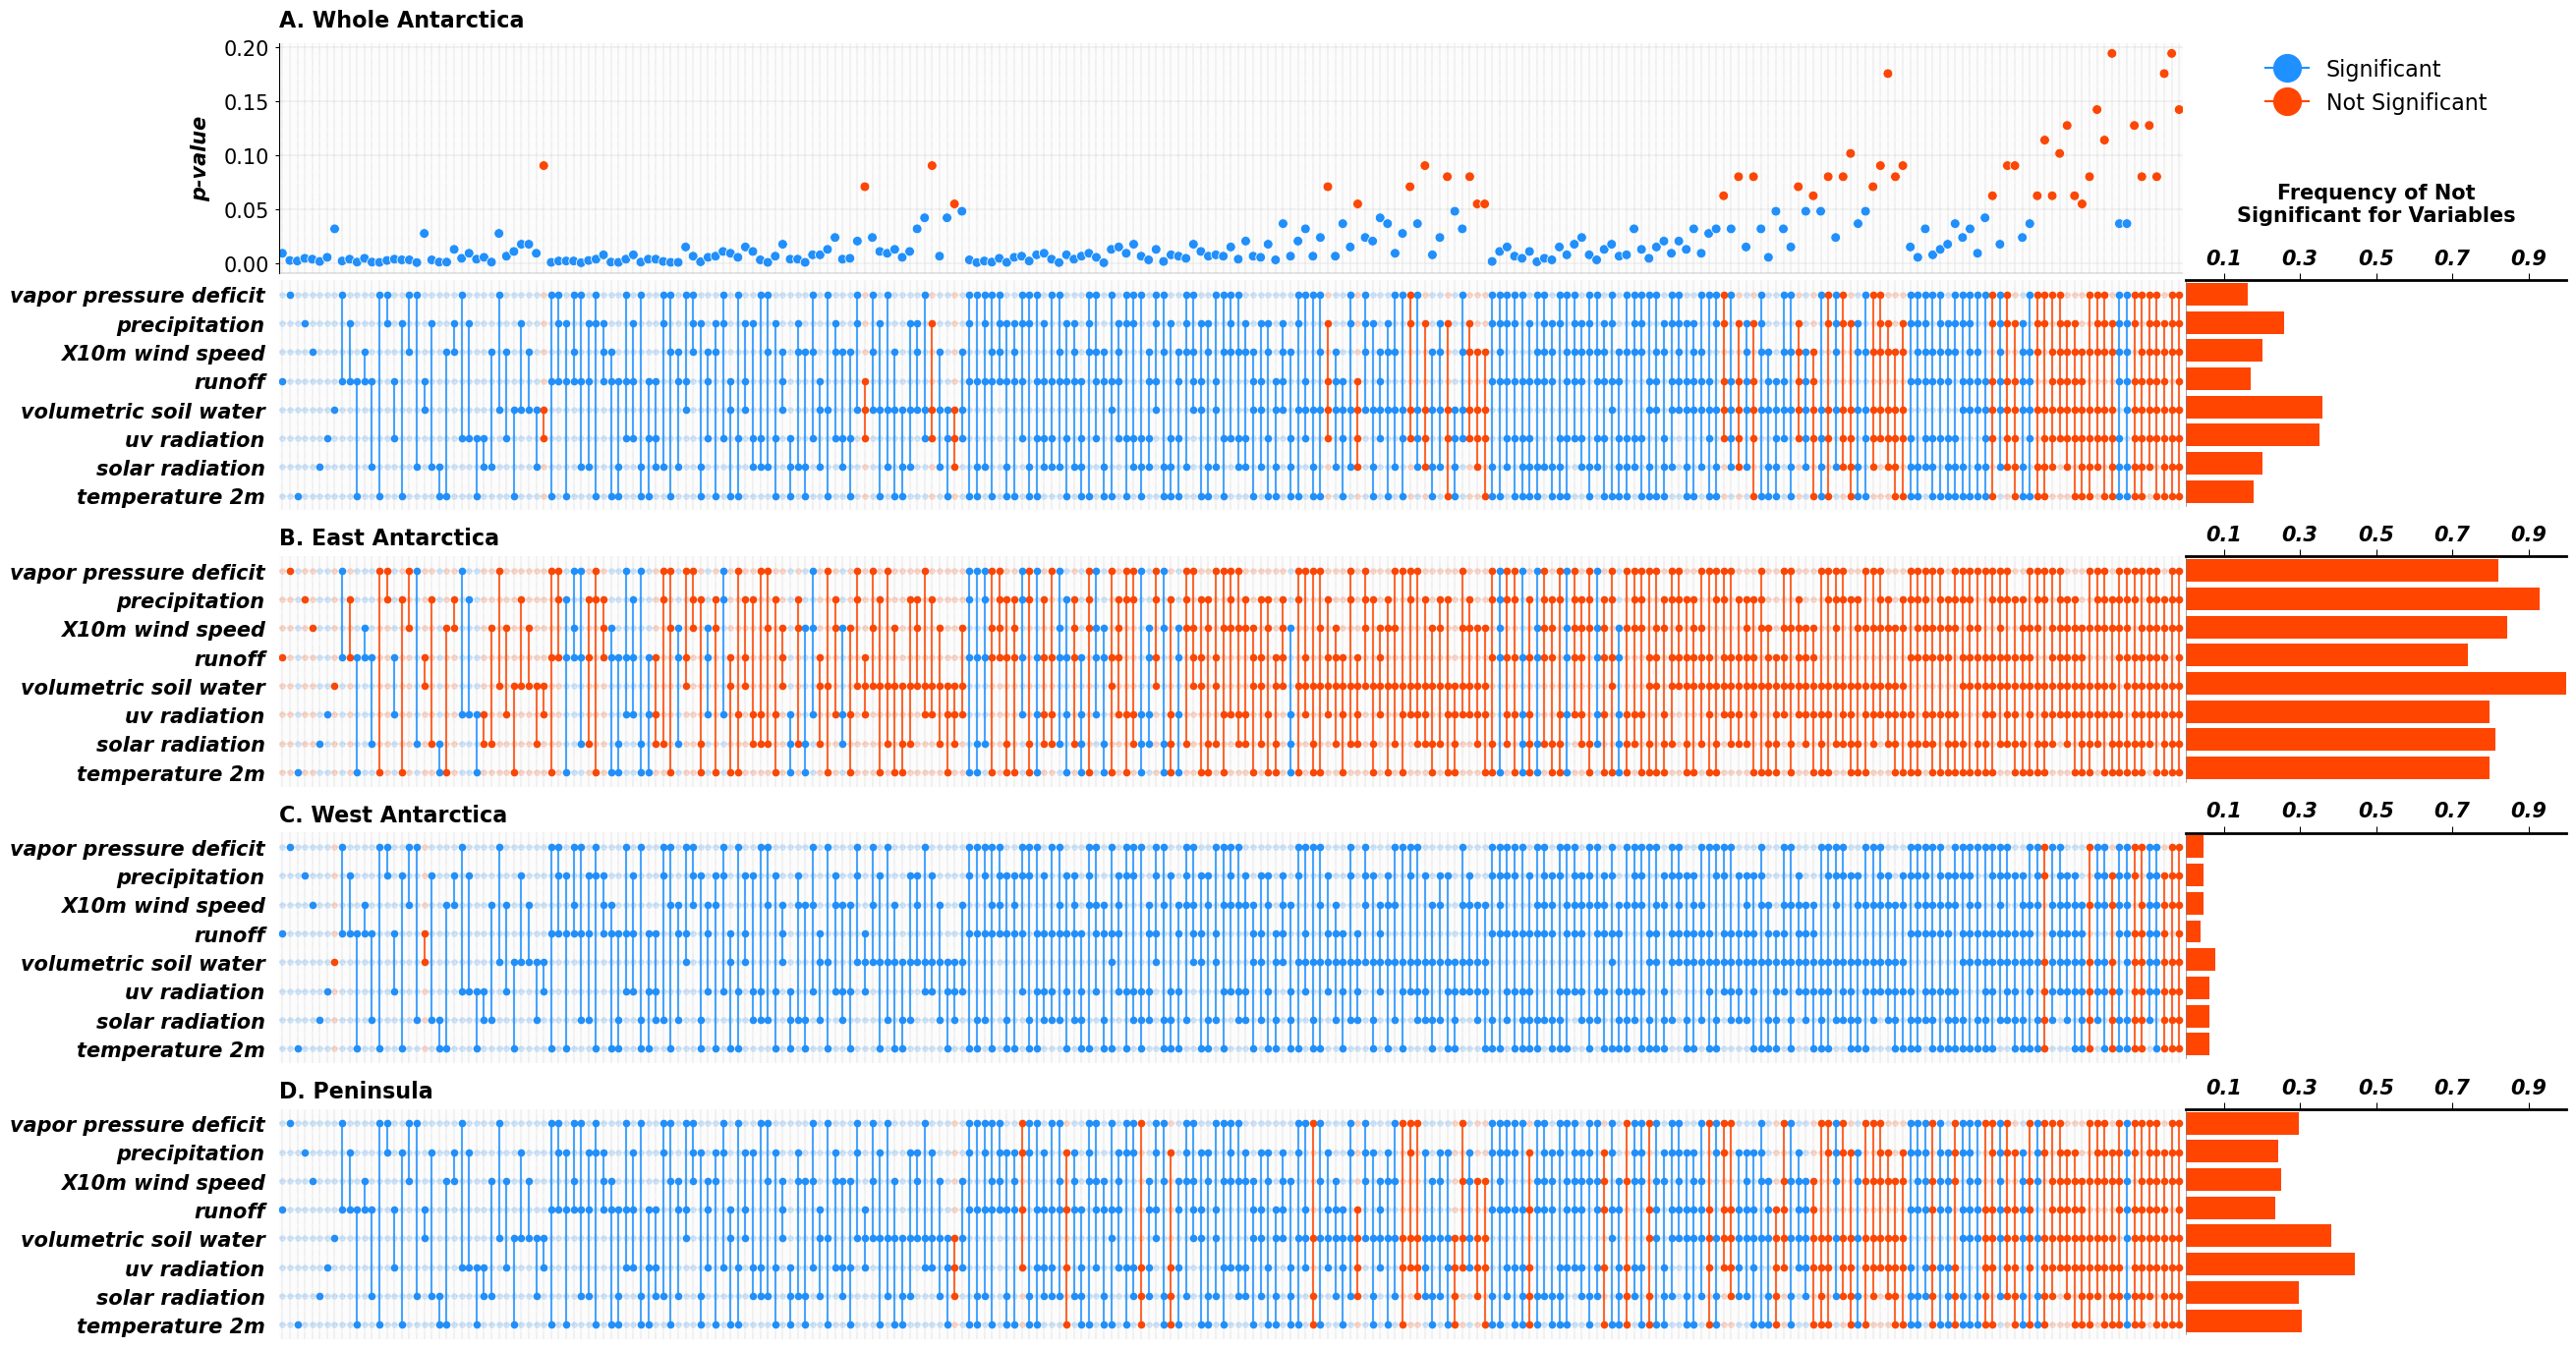

In [24]:
## old code

# fig,(ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize = (25,14))

# axes = [ax1, ax2, ax3, ax4]
# values = [values1, values2, values3, values4]
# text = ["A. Whole Antarctica", "B. East Antarctica", "C. West Antarctica", "D. Peninsula"]

# for idx, ax in enumerate(axes):
#     value = values[idx]

#     ax.set_facecolor((0,0,0,0.01))
#     ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
#     ax.grid(color='gray', linestyle=':', linewidth=0.3)
    
#     if idx == 0:
#         ax_inset = inset_axes(ax, width="100%", height="100%", bbox_to_anchor=(0, 1, 1, 1),loc='lower center' ,bbox_transform=ax.transAxes)
#         ax_inset.set_facecolor((0,0,0,0.01))
#         ax_inset.xaxis.set_major_locator(ticker.MultipleLocator(1))
#         ax_inset.grid(color='gray', linestyle=':', linewidth=0.3)
        
#         sns.scatterplot(x = "idx", y = "values", hue = "symbols", data = value,style="symbols",markers={True: "o", False: "o"}, 
#                 palette=["orangered", "dodgerblue"],s = 50)
#         ax_inset.set_xlim(value["idx"].min()-0.5, values1["idx"].max()+0.5)

#         ax_inset.spines[['top', 'right']].set_visible(False)
#         ax_inset.spines[['bottom']].set_color("gray")
#         ax_inset.spines['bottom'].set_linewidth(0.3)
#         ax_inset.set_xlabel('')
#         ax_inset.tick_params(axis='both', which='major', direction='out', length=3, labelsize=15, 
#                    bottom = False, top = False, left = True, right = False,
#                    labelbottom = False, labeltop = False, labelleft = True, labelright = False)
#         ax_inset.set_ylabel("p-value",labelpad = 10, fontweight='bold',fontstyle='italic',fontsize=15)
#         ax_inset.legend_.remove()


#     dd = pd.DataFrame(index.tolist(), columns=index.names).astype(int)
#     for i in range(len(dd)): 
#         color = "dodgerblue" if value[value["idx"] == i]["symbols"].values[0] else "orangered"
#         for j in range(dd.shape[1]):
#             if dd.iloc[i, j]:
#                 ax.scatter(i, j, color=color, s=20, alpha=1)
#             else:
#                 ax.scatter(i, j, color=color, s=15, alpha=0.15)
                
#     for i in range(len(dd)):
#         color = "dodgerblue" if value[value["idx"] == i]["symbols"].values[0] else "orangered"
#         active_indices = np.where(dd.iloc[i].values == 1)[0] 
#         if len(active_indices) > 1:
#             ax.plot([i] * len(active_indices), active_indices, color=color, linewidth=1.5, alpha = 0.8)
    
    
#     frequency_false = []
#     frequency_true = []
#     df = pd.concat([value, dd], axis = 1)
#     for col in dd.columns:
#         df_filter = df[["symbols", col]]
#         df_filter = df_filter[df_filter[col] == 1]

#         total = df_filter.shape[0]
#         false_count = (df_filter["symbols"] == False).sum()
#         false_ratio = false_count / total

#         true_count = (df_filter["symbols"] == True).sum()
#         true_ratio = true_count / total

#         frequency_false.append(false_ratio)
#         frequency_true.append(true_ratio)
    
#     ax_side = inset_axes(ax, width="20%", height="98%", bbox_to_anchor=(0.205, -0.01, 1, 1),loc='lower right' ,bbox_transform=ax.transAxes)
#     ax_side.barh(np.arange(len(dd.columns)), frequency_false, color = "orangered")
#     ax_side.set_ylim(-0.5, len(dd.columns) - 0.5)
#     ax_side.tick_params(axis='both', which='major', direction='out', length=5, labelsize=15, 
#                    bottom = False, top = True, left = True, right = False,
#                    labelbottom = False, labeltop = True, labelleft = True, labelright = False)
#     ax_side.tick_params(axis='y', which='major', direction='out', length=0)
    
#     ax_side.spines[['bottom', 'right']].set_visible(False)
#     ax_side.spines[['left']].set_color("gray")
#     ax_side.spines[['left']].set_linewidth(0.5)
#     ax_side.spines[['top']].set_linewidth(2)
#     ax_side.set_yticklabels([])
#     ax_side.set_xlim(0,1)
    
#     xticks = np.arange(0.1, 1.1, 0.2)
#     labels = [f"{v:.1f}" for v in xticks]

#     ax_side.set_xticks(xticks)
#     ax_side.set_xticklabels(labels, fontweight='bold', style='italic', fontsize = 15)
#     ax_side.xaxis.set_label_position('top')
#     ax_side.set_xlabel("Frequency of Not\nSignificant for Variables", fontsize=15, labelpad = 20, fontweight='bold')
# #     ax_side.set_xticklabels([]) if idx !=0 else None
#     ax_side.set_xlabel('') if idx !=0 else None

#     #############################################################################################3
#     ax.set_xlim(value["idx"].min()-0.5, value["idx"].max()+0.5)
#     ax.set_yticks(range(len(dd.columns)))
#     ax.set_yticklabels(dd.columns, fontweight='bold',fontstyle='italic',fontsize=15)
#     ax.set_ylim(-0.5, len(dd.columns) - 0.5)
#     ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
#     ax.tick_params(axis='both', which='major', direction='out', length=0, labelsize=15,pad = 0,
#                    bottom = False, top = False, left = True, right = False,
#                    labelbottom = False, labeltop = False, labelleft = True, labelright = False)
#     ax.tick_params(axis='y', pad=10)
#     y_loc = 2.1 if idx ==0 else 1.05
#     ax.text(0,y_loc, f'{text[idx]}', transform=ax.transAxes, fontsize = 16, fontweight='bold')
    
#     if idx == 0:
# #         colors = ["limegreen", "dodgerblue"]
# #         colors = ["limegreen", "orangered"]
#         colors = ["dodgerblue", "orangered"]
#         handles = []
#         labels = ["Significant", "Not Significant"]
#         for i in range(2):
#             handle = Line2D([0], [0], marker="o", color=colors[i], label=labels[i],
#                             markerfacecolor=colors[i], markersize=20)
#             handles.append(handle)

#         ax.legend(handles, labels, loc='upper right',fontsize = 16,frameon = 'none',bbox_to_anchor=(1.17, 2.05),
#                   facecolor = 'none',edgecolor = 'none',ncol = 1, columnspacing=2)
# plt.savefig('/Users/jifujiang/Desktop/Antarctic_greenning_mapping/2_exported_figures/Figure_4 Significace for different variables combination3.png', dpi=1000, bbox_inches='tight') 